# **Question Answering Model for SQuAD dataset**

### Import needed library dependencies 

In [ ]:
import json 
import torch

import pandas as pd
import torch.nn as nn

from torchtext.legacy.data import Dataset
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

### Mount GPU resources (if available)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')
torch.cuda.empty_cache()

Using cuda device


### Install transformers

In [ ]:
!pip install transformers

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForQuestionAnswering, BertTokenizerFast, BertForQuestionAnswering
from transformers import AdamW

### Reading training dataset from json

We do also remove the "version" field since we do not need it at all

In [ ]:
df = pd.read_json('../input/squad-20/train-v2.0.json')
del df["version"]
df.head()

,data
0,"{'title': 'Beyoncé', 'paragraphs': [{'qas': [{..."
1,"{'title': 'Frédéric_Chopin', 'paragraphs': [{'..."
2,{'title': 'Sino-Tibetan_relations_during_the_M...
3,"{'title': 'IPod', 'paragraphs': [{'qas': [{'qu..."
4,{'title': 'The_Legend_of_Zelda:_Twilight_Princ...


### Reading evaluation dataset from json

In [ ]:
df_test = pd.read_json('../input/squad-20/dev-v2.0.json')
del df_test["version"]
df_test.head()

,data
0,"{'title': 'Normans', 'paragraphs': [{'qas': [{..."
1,"{'title': 'Computational_complexity_theory', '..."
2,"{'title': 'Southern_California', 'paragraphs':..."
3,"{'title': 'Sky_(United_Kingdom)', 'paragraphs'..."
4,"{'title': 'Victoria_(Australia)', 'paragraphs'..."


### Prepare data 

We extract only the fields we need for the question/answer task. Thus, function prepare_data extracts the questions, context and answers field from the jsons given as input and returns a dictionary with these three fields: question, context, answer

In [ ]:
def prepare_data(df):
    comp_list = []
    contextList = []
    qList = []
    aList = []

    for index, row in df.iterrows():
        for par in row[0]['paragraphs']:
          for qa in par["qas"]:
            for a in qa["answers"]:
              contextList.append(par["context"])
              qList.append(qa["question"])
              aList.append(a)

    return { 'question': qList,
            'context': contextList,
            'answers': aList}

data = prepare_data(df)
test_data = prepare_data(df_test)
data['answers'][:5]

[{'text': 'in the late 1990s', 'answer_start': 269},
 {'text': 'singing and dancing', 'answer_start': 207},
 {'text': '2003', 'answer_start': 526},
 {'text': 'Houston, Texas', 'answer_start': 166},
 {'text': 'late 1990s', 'answer_start': 276}]

### **Update answer start and add answer end field in data**

Function add_end_idx finds  out character position at which the answer ends in the passage. It also corrects answer start and end position if the SQuAD answers are off by one or two characters. Thus, we have the exact passage that the answer is expected to be found.

In [ ]:
## Function to update answer_start and answer_end 
def add_end_idx(answers, contexts):
    for answer, context in zip(answers, contexts):
        # Your code here
        if answer['answer_start'] is None:
            answer['answer_end'] = None
        else:
            answer_text  = answer['text']
            answer_start = answer['answer_start']
            answer_end   = len(answer_text) + answer_start

            #Sometimes answers are off by a character or two
            if context[answer_start:answer_end] == answer['text']:
                answer['answer_end'] = answer_end
            # If the answer text is off by 1 character
            elif context[answer_start-1:answer_end-1] == answer_text:
                answer['answer_start'] = answer_start - 1
                answer['answer_end'] = answer_end - 1     
            # If the answer text is off by 2 characters
            elif context[answer_start-2:answer_end-2] == answer_text:
                answer['answer_start'] = answer_start - 2
                answer['answer_end'] = answer_end - 2 

In [ ]:
add_end_idx(data["answers"], data["context"])
add_end_idx(test_data["answers"], test_data["context"])

In [ ]:
data['answers'][:5]

[{'text': 'in the late 1990s', 'answer_start': 269, 'answer_end': 286},
 {'text': 'singing and dancing', 'answer_start': 207, 'answer_end': 226},
 {'text': '2003', 'answer_start': 526, 'answer_end': 530},
 {'text': 'Houston, Texas', 'answer_start': 166, 'answer_end': 180},
 {'text': 'late 1990s', 'answer_start': 276, 'answer_end': 286}]

In [ ]:
test_data['answers'][:5]

[{'text': 'France', 'answer_start': 159, 'answer_end': 165},
 {'text': 'France', 'answer_start': 159, 'answer_end': 165},
 {'text': 'France', 'answer_start': 159, 'answer_end': 165},
 {'text': 'France', 'answer_start': 159, 'answer_end': 165},
 {'text': '10th and 11th centuries', 'answer_start': 94, 'answer_end': 117}]

### **Tokenization of context and questions**

In [ ]:
#tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

train = tokenizer(data['context'], data['question'], truncation=True, padding='max_length', max_length=512, return_tensors='pt') 
tokenizer.decode(train['input_ids'][0])[:100]

Downloading:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/455k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

'[CLS] beyonce giselle knowles - carter ( / biːˈjɒnseɪ / bee - yon - say ) ( born september 4, 1981 )'

In [ ]:
test = tokenizer(test_data['context'], test_data['question'], truncation=True, padding='max_length', max_length=512, return_tensors='pt') 
tokenizer.decode(test['input_ids'][0])[:50]

'[CLS] the normans ( norman : nourmands ; french : '

### **Convert answer_start and answer_end fields to tokens**

The Bert model feeds on tokens. Previously with function *add_end_idx*, we found and added in our data each answer's end position. With *add_token_in_position* we convert the start and end characters into tokens to align with the model's input requirments.

After calling this function, two more tensors are added in our previously tokenized data (tensors: start_position & end_position).

In [ ]:
def add_token_positions(encodings, answers):
    # initialize lists to contain the token indices of answer start/end
    start_positions = []
    end_positions = []
    for i in tqdm(range(len(answers))):
        # append start and end token position using
        start_positions.append(encodings.char_to_token(i, answers[i]['answer_start']))
        end_positions.append(encodings.char_to_token(i, answers[i]['answer_end']))

        # if start position is None, the answer passage has been truncated
        if start_positions[-1] is None:
            start_positions[-1] = tokenizer.model_max_length
        # If the end position cannot be found (char_to_token found space), we shift position until found
        shift = 1
        while end_positions[-1] is None:
            end_positions[-1] = encodings.char_to_token(i, answers[i]['answer_end'] - shift)
            shift += 1
    # update our encodings object with the new token-based start/end positions
    encodings.update({'start_positions': start_positions, 'end_positions': end_positions})

In [ ]:
add_token_positions(train, data['answers'])
add_token_positions(test, test_data['answers'])

  0%|          | 0/86821 [00:00<?, ?it/s]

  0%|          | 0/20302 [00:00<?, ?it/s]

### **Create custom Dataset class for SqUAD data**

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, encodings, device='cpu'):
    self.device = device
    self.encodings = encodings

  def __len__(self):
    return len(self.encodings.input_ids)

  def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


dataset = CustomDataset(train, device)
eval_dataset = CustomDataset(test, device)

### **Load data and create batches**

In [ ]:
pin_memory = False
if(device == 'cuda'):
  pin_memory = True

print(pin_memory)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, pin_memory=pin_memory)
eval_dataloader = DataLoader(eval_dataset, batch_size=8, shuffle=True, pin_memory=pin_memory)

True


### **Define model parameters**

Here, we define the number of epochs for the model's training process. We also load the model of our choice (in this case *BertForQuestionAnswering* and the optimizer. 

The learning rate that gives better results after some experiments run in smaller parts of the initial dataset is 5e-5, which is actually the bottom threshold most suggest for these kind of qa-models.

In [ ]:
N_EPOCHS = 4

net = BertForQuestionAnswering.from_pretrained("bert-base-uncased")

for name, param in net.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

LR = 5e-5
optimizer = AdamW(net.parameters(), lr=LR)
net.to(device)

Downloading:   0%|          | 0.00/420M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForQuestionAnswering: ['cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased a

bert.embeddings.word_embeddings.weight torch.Size([30522, 768])
bert.embeddings.position_embeddings.weight torch.Size([512, 768])
bert.embeddings.token_type_embeddings.weight torch.Size([2, 768])
bert.embeddings.LayerNorm.weight torch.Size([768])
bert.embeddings.LayerNorm.bias torch.Size([768])
bert.encoder.layer.0.attention.self.query.weight torch.Size([768, 768])
bert.encoder.layer.0.attention.self.query.bias torch.Size([768])
bert.encoder.layer.0.attention.self.key.weight torch.Size([768, 768])
bert.encoder.layer.0.attention.self.key.bias torch.Size([768])
bert.encoder.layer.0.attention.self.value.weight torch.Size([768, 768])
bert.encoder.layer.0.attention.self.value.bias torch.Size([768])
bert.encoder.layer.0.attention.output.dense.weight torch.Size([768, 768])
bert.encoder.layer.0.attention.output.dense.bias torch.Size([768])
bert.encoder.layer.0.attention.output.LayerNorm.weight torch.Size([768])
bert.encoder.layer.0.attention.output.LayerNorm.bias torch.Size([768])
bert.encoder

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_

### **Train model and Fine Tuning**

We train the model for 4 epochs. During each epoch the model passes through two phases.



*   In train phase the model takes in batches the train data and at the end of each epoch we see the train loss. We can see that after each epoch the loss subsides, while by the end of the last epoch it is ~0.556.
*   In evaluation phase, the model evaluates the progress it has made after the training of its current epoch.



In [ ]:
train_stats = []
eval_stats = []

for epoch in range(N_EPOCHS):
  batch_losses = []
  prediction = []
  running_loss = 0.0
  i=0

  # Ensure net in training mode
  net.train()
  for i, batch in enumerate(dataloader):
    # Zero out gradients
    optimizer.zero_grad()
    
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    start_positions = batch['start_positions'].to(device)
    end_positions = batch['end_positions'].to(device)

    output = net(input_ids, attention_mask=attention_mask, start_positions=start_positions, end_positions=end_positions)
    
    loss = output[0]
    loss.backward()
    optimizer.step()
    
    # Track loss
    # CE loss
    batch_losses.append(loss.item())
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)     

  print(f"Epoch {epoch:3}: Loss = {float(running_loss)}")

  train_stats.append(float(running_loss))
    
  net.eval()
  running_loss_val = 0.0
  for i, batch in enumerate(eval_dataloader):
    with torch.no_grad():
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        start_positions = batch['start_positions'].to(device)
        end_positions = batch['end_positions'].to(device)
        y_pred = net(input_ids, attention_mask=attention_mask, start_positions=start_positions, end_positions=end_positions)

        loss = loss = output[0]

        current_loss = loss.item()
        running_loss += (current_loss - running_loss) / (i + 1)

        prediction.append(y_pred)
  
  eval_stats.append(running_loss).

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  # Remove the CWD from sys.path while we load stuff.


Epoch   0: Loss = 1.326576458171273
Epoch   1: Loss = 0.8733867455040799
Epoch   2: Loss = 0.6839231459375325
Epoch   3: Loss = 0.5563857170203049


### Train and Validation Losses

In [ ]:
train_stats_df = pd.DataFrame(list(zip(train_stats, eval_stats)), columns=['train_loss', 'val_loss'])
display(train_stats_df)

,train_loss,val_loss
0,1.326576,0.943566
1,0.873387,1.258249
2,0.683923,1.429524
3,0.556386,0.543381


### Plot of train and validation losses

In the plot below we can see that the training loss looks like a good fit, since it diminishes through the epochs.
The validation loss line in the first three epochs appears to be increasing. After the last epoch though that the model can be considered fully trained we see that it drops and meets the train loss line. It actually seems to stop at a quite golden point, since a bit lower and we could consider it overfitted.

The experiments run focused in four axes:

1. The number of data given as input to the model. This did not really seem to affect its performance for the best. Actually, since the model has less information available to learn from, the evaluation performance does not fair well. Thus we conclude that the more data we feed it, the merrier.

2. The number of entries each batch we feed during the model's training was also under some experimentation. First due to limited resources we could not really experiment with big numbers, and second it was observed that the smaller the batches the better for our model's performance. This is something we already know from theory. Thus, we observe the loss of our model rapidly falling from one epoch to the next.

3. Another parameter that makes the difference is the learning rate. It is suggested in all sources that the learning rate for this kind of problems should be low. Indeed, after trying to train the model with values like 1e-3, 1e-5 and others, we concluded that the best choice was 5e-5. With this value the model has the following curve for its training losses.(x=loss, y=epochs)

4. The number of epochs, with 4 being the best number to avoid excess overfit or underfit.

<AxesSubplot:>

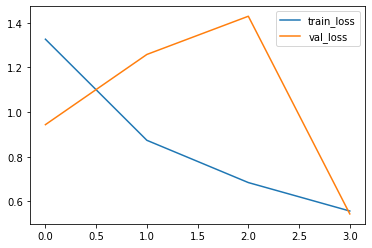

In [ ]:
train_stats_df.plot()

In [ ]:
torch.save(net,"bert_qa_squad")

### Save fine-tuned model 

In [ ]:
net = torch.load("./bert_qa_squad", map_location=torch.device('cpu'))
net.eval()

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_

### **Evaluate model with *dev-dataset***

The following functions are used to predict the answer to the questions asked to the model and calculate the F1 measure and exact score. [source](https://qa.fastforwardlabs.com/no%20answer/null%20threshold/bert/distilbert/exact%20match/f1/robust%20predictions/2020/06/09/Evaluating_BERT_on_SQuAD.html)

In [ ]:
def get_prediction_for_question(question, context):
    inputs = tokenizer.encode_plus(question, context, truncation=True, padding='max_length', max_length=512, return_tensors='pt').to('cpu')
    
    net.to('cpu')
    outputs = net(**inputs)
    answer_start = torch.argmax(outputs[0])  # get the most likely beginning of answer with the argmax of the score
    answer_end = torch.argmax(outputs[1]) + 1 

    answer = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0][answer_start:answer_end]))

    return answer    

def normalize_text(s):
  """Removing articles and punctuation, and standardizing whitespace are all typical text processing steps."""
  import string, re

  def remove_articles(text):
    regex = re.compile(r"\b(a|an|the)\b", re.UNICODE)
    return re.sub(regex, " ", text)

  def white_space_fix(text):
    return " ".join(text.split())

  def remove_punc(text):
    exclude = set(string.punctuation)
    return "".join(ch for ch in text if ch not in exclude)

  def lower(text):
    return text.lower()

  return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_exact_match(prediction, truth):
    return int(normalize_text(prediction) == normalize_text(truth))

def compute_f1(prediction, truth):
  pred_tokens = normalize_text(prediction).split()
  truth_tokens = normalize_text(truth).split()
  
  # if either the prediction or the truth is no-answer then f1 = 1 if they agree, 0 otherwise
  if len(pred_tokens) == 0 or len(truth_tokens) == 0:
    return int(pred_tokens == truth_tokens)
  
  common_tokens = set(pred_tokens) & set(truth_tokens)
  
  # if there are no common tokens then f1 = 0
  if len(common_tokens) == 0:
    return 0
  
  prec = len(common_tokens) / len(pred_tokens)
  rec = len(common_tokens) / len(truth_tokens)
  
  return 2 * (prec * rec) / (prec + rec)

def get_prediction_measures(question,answer, context):
  prediction = get_prediction_for_question(context,question)
  exact_match_score = compute_exact_match(prediction, answer)
  f1_score = compute_f1(prediction, answer)
  return exact_match_score, f1_score

def predict_answer(question,answer, context):

  prediction = get_prediction_for_question(context,question)
  exact_match_score = compute_exact_match(prediction, answer)
  f1_score = compute_f1(prediction, answer)

  print(f"Question: {question}")
  print(f"Prediction: {prediction}")
  print(f"True Answer: {answer}")
  print(f"EM: {exact_match_score} \t F1: {f1_score}\n")

### **Selected Examples**

Below we see four in total selected examples. The first two are from the squad dataset, while the last two are from the triviaqa dataset. 
In both cases we see the F1 score for each answer. With the exception of an impossible question, overall the answers given are satisfying for the examples of both datasets.

In [ ]:
questions = ["In what country is Normandy located?", 
             "When were the Normans in Normandy?",
             "From which countries did the Norse originate?",
             "Who was the Norse leader?",
             "What century did the Normans first gain their separate identity?"]

answers = ["France", 
           "10th and 11th centuries", 
           "Denmark, Iceland and Norway", 
           "Rollo", 
           "10th century"]             


context = """The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, 
a region in France. They were descended from Norse (\"Norman\" comes from \"Norseman\") raiders and pirates from Denmark, Iceland and Norway who, under their 
leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish 
populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans 
emerged initially in the first half of the 10th century, and it continued to evolve over the succeeding centuries."""             
input = zip(questions, answers)
for q, a in input:
    predict_answer(q, a, context)

Question: In what country is Normandy located?
Prediction: france.
True Answer: France
EM: 1 	 F1: 1.0

Question: When were the Normans in Normandy?
Prediction: 10th and 11th centuries
True Answer: 10th and 11th centuries
EM: 1 	 F1: 1.0

Question: From which countries did the Norse originate?
Prediction: denmark, iceland and norway
True Answer: Denmark, Iceland and Norway
EM: 1 	 F1: 1.0

Question: Who was the Norse leader?
Prediction: rollo,
True Answer: Rollo
EM: 1 	 F1: 1.0

Question: What century did the Normans first gain their separate identity?
Prediction: 10th
True Answer: 10th century
EM: 0 	 F1: 0.6666666666666666



In [ ]:
questions = ["Who did Emma Marry?", 
             "Who was Emma's brother?",
             "To where did Ethelred flee?",
             "Who kicked Ethelred out?",
             "When did Richard II flee to Normandy?"]

answers = ["King Ethelred II", 
           "Duke Richard II", 
           "Normandy", 
           "Sweyn Forkbeard", 
           "is_impossible"]             


context = """The Normans were in contact with England from an early date. Not only were their original Viking brethren still ravaging the English coasts, 
    they occupied most of the important ports opposite England across the English Channel. This relationship eventually produced closer ties of blood through 
    the marriage of Emma, sister of Duke Richard II of Normandy, and King Ethelred II of England. Because of this, Ethelred fled to Normandy in 1013, when he 
    was forced from his kingdom by Sweyn Forkbeard. His stay in Normandy (until 1016) influenced him and his sons by Emma, who stayed in Normandy after Cnut 
    the Great's conquest of the isle."""            
input = zip(questions, answers)
for q, a in input:
    predict_answer(q, a, context)

Question: Who did Emma Marry?
Prediction: king ethelred ii of england.
True Answer: King Ethelred II
EM: 0 	 F1: 0.7499999999999999

Question: Who was Emma's brother?
Prediction: duke richard ii
True Answer: Duke Richard II
EM: 1 	 F1: 1.0

Question: To where did Ethelred flee?
Prediction: normandy
True Answer: Normandy
EM: 1 	 F1: 1.0

Question: Who kicked Ethelred out?
Prediction: sweyn forkbeard.
True Answer: Sweyn Forkbeard
EM: 1 	 F1: 1.0

Question: When did Richard II flee to Normandy?
Prediction: 1013,
True Answer: is_impossible
EM: 0 	 F1: 0



In [ ]:
questions = ["Dave Gilmore and Roger Waters were in which rock group?"]

answers = ["Pink Floyd"]


context = """George Roger Waters ( born 6 September 1943 ) is an English singer , songwriter , multi-instrumentalist , and composer . In 1965 , he 
co-founded the progressive rock band Pink Floyd with drummer Nick Mason , keyboardist Rick Wright and guitarist , singer , and songwriter Syd Barrett . 
Waters initially served as the group 's bassist , but following the departure of Barrett in 1968 , he also became their lyricist , conceptual leader and 
co-lead vocalist . Waters had the 9th widest vocal range on a list of over 150 contemporary Rock & Pop singers , with a total range of B1-C7 , with the 
magazine commenting `` He 's not a tenor , he 's a mutation . '' \n \n Pink Floyd subsequently achieved international success with the concept albums 
The Dark Side of the Moon , Wish You Were Here , Animals , and The Wall . By the early 1980s , they had become one of the most critically acclaimed and 
best-selling acts in the history of popular music ; as of 2013 , they have sold more than 250 million albums worldwide . Amid creative differences within 
the group , Waters left in 1985 and began a legal dispute with the remaining members over their intended use of the band 's name and material . They 
settled out of court in 1987 , and nearly eighteen years passed before he performed with them again . \n \n Waters ' solo career has included three studio 
albums : The Pros and Cons of Hitch Hiking , Radio K.A.O.S . and Amused to Death . In 1990 , he staged one of the largest and most extravagant rock concerts 
in history , The Wall – Live in Berlin , with an official attendance of 200,000 . As a member of Pink Floyd , he was inducted into the U.S. Rock and Roll 
Hall of Fame in 1996 and the UK Music Hall of Fame in 2005 . That same year he released ' , an opera in three acts translated from Étienne and Nadine 
Roda-Gils ' libretto about the French Revolution . Later that year , he reunited with Pink Floyd bandmates Mason , Wright and David Gilmour for the 
Live 8 global awareness event ; it was the group 's first appearance with Waters since 1981 . He has toured extensively as a solo act since 1999 and 
played The Dark Side of the Moon in its entirety for his world tour of 2006–2008 . In 2010 , he began The Wall Live and in 2011 Gilmour and Mason appeared 
with him during a performance of the double-album in London . As of 2013 , the tour is the highest-grossing of all time by a solo artist . \n \n 1943–1964 : 
Early years \n \n George Roger Waters was born on 6 September 1943 , the younger of two boys , to Mary ( née Whyte ; 1913–2009 ) and Eric Fletcher Waters ( 1914–1944 ) , 
in Great Bookham , Surrey . His father , the son of a coal miner and Labour Party activist , was a schoolteacher , a devout Christian , and a Communist Party member . 
In the early years of the Second World War , his father was a conscientious objector who drove an ambulance during the Blitz . He later changed his stance on pacifism 
and joined the British Army , and as a 2Lt . of the 8th Royal Fusiliers died at Aprilia , between Anzio and Rome in Italy , on 18 February 1944 , when Roger was five 
months old . On 19 February 2014 , Waters unveiled a monument to his father and other war casualties there , and was made an honorary citizen of Anzio . Following her 
husband 's death , Mary Waters , also a teacher , moved with her two sons to Cambridge and raised them there . Roger Waters ' earliest memory is of the VJ Day celebrations . 
Mary Waters died in 2009 , aged 96 . \n \n Waters attended Morley Memorial Junior School in Cambridge and then the Cambridgeshire High School for Boys 
( now Hills Road Sixth Form College ) with Syd Barrett , while his future musical partner , David Gilmour , lived nearby on the city 's Mill Road , and attended the Perse School . 
At 15 , Waters was chairman of the Cambridge Youth Campaign for Nuclear Disarmament ( YCND ) , having designed its publicity poster and participated in its organisation . 
Though he was a keen sportsman and a highly regarded member of the high school 's cricket and rugby teams , he disliked his educational experience ; according to Waters , `` I hated every"""

input = zip(questions, answers)
for q, a in input:
    predict_answer(q, a, context)

Question: Dave Gilmore and Roger Waters were in which rock group?
Prediction: pink floyd
True Answer: Pink Floyd
EM: 1 	 F1: 1.0



In [ ]:
questions = ["Who was the target of the failed \"\"Bomb Plot\"\" of 1944?"]

answers = ["Adolf Hitle"]


context = """On 20 July 1944 , an attempt was made to assassinate Adolf Hitler , Führer of Nazi Germany , perpetrated by Claus von Stauffenberg and other conspirators , 
    inside his Wolf 's Lair field headquarters near Rastenburg , East Prussia . The name Operation Valkyrie , originally referring to a component part of the conspirators ' 
    overall plot , has become associated with the event . The apparent purpose of the assassination attempt was to seize political control of Germany and its armed forces from 
    the Nazi Party ( including the SS ) in order to obtain peace with the western Allies as soon as possible . The underlying desire of many of the involved high ranking 
    Wehrmacht officers was apparently to show to the world that not all Germans were like Hitler and the Nazi Party . The details of the conspirators ' peace initiatives 
    remain unknown , but they likely would have included demands to accept wide-reaching territorial annexations by Germany in Europe . \n \n The plot was the culmination of 
    the efforts by several groups in the German Resistance to overthrow the Nazi-led German government . The failure of both the assassination and the military coup d'état 
    which was planned to follow , led to the arrest of at least 7,000 people by the Gestapo . According to records of the Führer Conferences on Naval Affairs , 4,980 of these 
    were executed . \n \n Background \n \n Since 1938 , conspiratorial groups planning an overthrow of some kind had existed in the German Army ( Wehrmacht Heer ) and in the 
    German Military Intelligence Organization ( Abwehr ) . Early leaders of these plots included Brigadier-General Hans Oster , General Ludwig Beck and Field Marshal Erwin von 
    Witzleben . Oster was the deputy head of the Military Intelligence Office . Beck was a former Chief-of-Staff of the German Army High Command ( Oberkommando des Heeres , OKH ) . 
    Von Witzleben was the former commander of the German 1st Army and the former Commander-in-Chief of the German Army Command in the West ( Oberbefehlshaber West , or OB West ) . 
    They soon established contacts with several prominent civilians , including Carl Goerdeler , the former mayor of Leipzig , and Helmuth James Graf von Moltke , the great-grandnephew 
    of the hero of the Franco-Prussian War . \n \n Military conspiratorial groups exchanged ideas with civilian , political , and intellectual resistance groups in the Kreisauer Kreis 
    ( which met at the von Moltke estate in Kreisau ) and in other secret circles . Moltke was against killing Hitler ; instead , he wanted him placed on trial . Moltke said , `` we are 
    all amateurs and would only bungle it '' . Moltke also believed killing Hitler would be hypocritical . Hitler and National Socialism had turned `` wrong-doing '' into a system , 
    something which the resistance should avoid . \n \n Plans to stage an overthrow and prevent Hitler from launching a new world war were developed in 1938 and 1939 , but were 
    aborted because of the indecision of Army Generals Franz Halder and Walther von Brauchitsch , and the failure of the Western powers to oppose Hitler 's aggression until 1939 . 
    This first military resistance group delayed their plans after Hitler 's extreme popularity following the unexpectedly rapid success in the battle for France . \n \n In 1942 , 
    a new conspiratorial group formed , led by Colonel Henning von Tresckow , a member of Field Marshal Fedor von Bock 's staff , who commanded Army Group Centre in Operation Barbarossa . 
    Tresckow systematically recruited oppositionists to the Group 's staff , making it the nerve centre of the army resistance . Little could be done against Hitler as he was heavily guarded , 
    and none of the plotters could get near enough to him . \n \n During 1942 , Oster and Tresckow nevertheless succeeded in rebuilding an effective resistance network . Their most important 
    recruit was General Friedrich Olbricht , head of the General Army Office headquarters at the Bendlerblock in central Berlin , who controlled an independent system of communications to 
    reserve units throughout Germany . Linking this asset to Tresckow 's resistance group in Army Group Centre created a viable coup apparatus . \n \n In late 1942 , Tresckow and Olbricht 
    formulated a plan to assassinate Hitler and stage an overthrow during Hitler 's visit to the headquarters of Army Group Centre at Smolensk in March 1943 , by placing a bomb on his 
    plane ( Operation Spark ) . The bomb failed to detonate , and a second attempt a week later with Hitler at an exhibition of captured Soviet weaponry in Berlin also failed . These failures 
    demoralised the conspirators"""

input = zip(questions, answers)
for q, a in input:
    predict_answer(q, a, context)

Question: Who was the target of the failed ""Bomb Plot"" of 1944?
Prediction: adolf hitler,
True Answer: Adolf Hitle
EM: 0 	 F1: 0.5



### **Squad Test Dataset Score**

Finally, we ask the model all the questions from the test dataset and get the following scores: 

F1 score = 0.69

Exact Match Score = 0.54

Support = 20302

In [ ]:
print(len(test_data['question']))
f1= 0.0
exact_match_score = 0.0
N = 0
questionList = []
answerList = []
contextList = []

for i in tqdm(range(len(test_data['question']))):
    questionList.append(test_data['question'][i])
    answerList.append(test_data['answers'][i]['text'])
    contextList.append(test_data['context'][i])


input = zip(questionList, answerList, contextList)
for q, a, c in input:
    cur_exact, cur_f1 = get_prediction_measures(q, a, c)
    exact_match_score = exact_match_score + cur_exact
    f1 = f1 + cur_f1
    N += 1

print("F1 sum=" + str(f1))
print("N=" + str(N))
print("EMS=" + str(exact_match_score))
print("F1 score =" + str(f1/N))        
print("Exact Match Score =" + str(exact_match_score/N))
print("Support = " + str(N))

20302


  0%|          | 0/20302 [00:00<?, ?it/s]

F1 sum=14066.980010744463
N=20302
EMS=10864.0
F1 score =0.6928864156607458
Exact Match Score =0.5351196926411191
Support = 20302


# **Sum Up**

To sum up, we trained two models that are supposed to be almost the same architecturally (Bert and DistilBert, with two different datasets. There is some vague space there due to the fact that DistilBert is a discounted version of Bert, however, the model obviously fairs better after trained with the squad dataset. 

Even during its trainning evaluation process the train loss and the eval loss relation has a better result by the end of the trainning in the Bert+Squad case. 

Finally, Bert+Squad had f1 score ~0.69 for the predictions it made for the questions found in the squad test dataset and came up with ~0.54 exact matches, which means that more than half of the questions were answered perfectly. 

On the other hand DIstilBert+TriviaQa had f1 score ~0.31 for the predictions it made for the questions found in the triviaqa test dataset and came up with ~0.28 exact matches. These results compared to Bert-Squad case, are dissapoining. Especially if we take into conisderation that this second model also fails to answer question posed ouside of its dataset, while Bert-Squad seems to answer them.